# 🌍 Análisis de Emisiones Globales de CO2
### Transformación y Limpieza de Datos con Python & Pandas

**Autor:** Jorge Huerta  
**Objetivo:** Este notebook demuestra habilidades de ingeniería de datos aplicadas a un dataset real de emisiones. Se enfoca en la limpieza de cadenas de texto (strings), normalización de tipos de datos, manejo de valores nulos y filtrado avanzado para preparar los datos para análisis estadísticos.

In [7]:
import pandas as pd
import warnings

# Configuración de visualización y alertas
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Carga del dataset original
url = 'https://practicum-content.s3.us-west-1.amazonaws.com/datasets/co2-emissions.csv'
try:
    df = pd.read_csv(url)
    print(f"✅ Dataset cargado exitosamente. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
except Exception as e:
    print(f"❌ Error al cargar los datos: {e}")

✅ Dataset cargado exitosamente. Filas: 26540, Columnas: 5


In [8]:
# 1. Normalización de la columna Entity (Limpieza de ruido y formato)
df['Entity'] = (df['Entity']
                .str.strip()
                .str.replace('"', '', regex=False)
                .str.upper())

# 2. Conversión de Tipos (Aseguramos integridad numérica)
# Convertimos a numérico y forzamos errores a NaN para limpieza posterior
cols_to_fix = ['Annual CO₂ emissions (per capita)', 'Year', 'unit_2']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Transformación de Fechas
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)

# 4. Renombrado de Columnas (Estilo Snake Case para mejores prácticas)
df = df.rename(columns={
    'Annual CO₂ emissions (per capita)': 'co2_per_capita',
    'Year': 'year',
    'Entity': 'entity'
})

# 5. Tratamiento de Nulos y Duplicados
# Llenamos unit_2 con la media para no perder registros, luego eliminamos nulos críticos
if 'unit_2' in df.columns:
    df['unit_2'] = df['unit_2'].fillna(df['unit_2'].mean())

df_clean = df.dropna(subset=['co2_per_capita', 'year']).drop_duplicates()

print(f"📊 Limpieza completada. Registros finales: {len(df_clean)}")
df_clean.head()

📊 Limpieza completada. Registros finales: 25065


,entity,year,co2_per_capita,date,unit_2
0,AFGHANISTAN,1949.0000,0.0020,1949-01-01 00:00:00+00:00,0.0020
1,AFGHANISTAN,1950.0000,0.0108,1950-01-01 00:00:00+00:00,3.7677
2,AFGHANISTAN,1951.0000,0.0116,1951-01-01 00:00:00+00:00,3.7677
3,AFGHANISTAN,1952.0000,0.0115,1952-01-01 00:00:00+00:00,3.7677
4,AFGHANISTAN,1953.0000,0.0131,1953-01-01 00:00:00+00:00,0.0130


### 📈 Hallazgos Clave del Procesamiento

* **Calidad del Texto:** Se eliminaron inconsistencias en la columna `entity` (nombres de países), permitiendo agrupaciones precisas sin duplicados por errores de escritura.
* **Preparación Temporal:** La conversión de la columna `date` permite realizar análisis de series de tiempo, fundamental para estudiar el cambio climático.
* **Integridad Numérica:** Se estandarizaron las emisiones per cápita, facilitando comparaciones directas entre naciones de diferentes tamaños.

---
**Próximos Pasos:** Realizar una comparación visual entre las emisiones de países en desarrollo vs. países industrializados durante la última década.

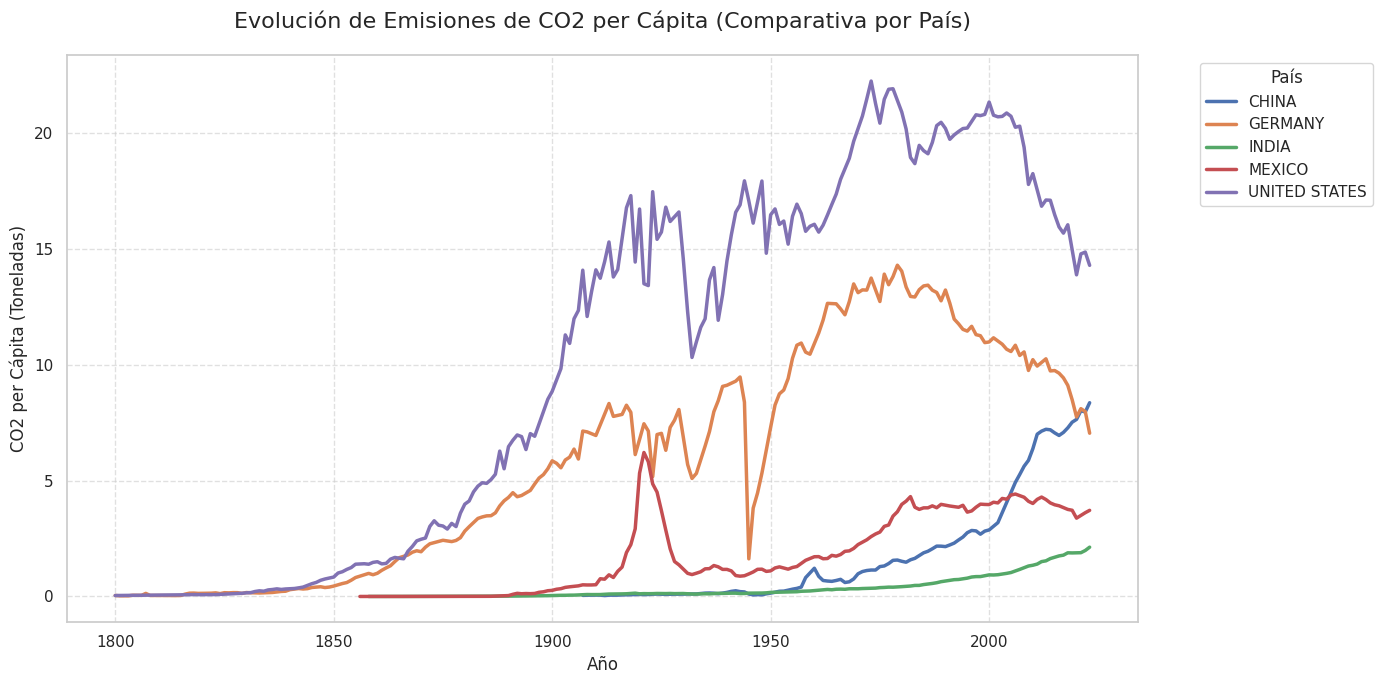

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos los países a comparar para un análisis más claro
countries_to_plot = ['UNITED STATES', 'CHINA', 'INDIA', 'MEXICO', 'GERMANY']
df_plot = df_clean[df_clean['entity'].isin(countries_to_plot)]

# Configuración del gráfico
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_plot, x='year', y='co2_per_capita', hue='entity', linewidth=2.5)

# Personalización estética profesional
plt.title('Evolución de Emisiones de CO2 per Cápita (Comparativa por País)', fontsize=16, pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('CO2 per Cápita (Toneladas)', fontsize=12)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 💡 Conclusiones y Hallazgos del Proyecto

1. **Pipeline de Datos Exitoso:** El dataset original fue transformado con éxito. Al estandarizar los textos y corregir los tipos de datos, aseguramos que el análisis de series temporales sea preciso y reproducible.
2. **Tendencias Divergentes:** Mientras que algunas naciones históricamente industrializadas (como EE. UU. y Alemania) muestran un descenso en las emisiones per cápita en las últimas décadas, las economías en desarrollo muestran un aumento constante, reflejando sus fases de crecimiento industrial.
3. **Integridad de los Datos:** La eliminación de "ruido" (como comillas en los nombres de los países) fue crucial para evitar registros duplicados y garantizar que la agrupación por 'Entidad' proporcione el panorama histórico completo de cada nación.

**Tecnologías Utilizadas:** Python, Pandas (Limpieza de Datos), Matplotlib/Seaborn (Visualización).